## 1) Installation des dépendances

In [6]:
!pip install emoji unidecode beautifulsoup4 spacy

# téléchargement des modèles spaCy anglais
!python -m spacy download en_core_web_sm



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 41.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2) Imports

In [7]:
import re
import emoji
import unidecode

from bs4 import BeautifulSoup

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download("punkt")
nltk.download("stopwords")

import spacy
nlp_en = spacy.load("en_core_web_sm")

import pandas as pd


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 3)Importation des données

In [8]:
import pandas as pd

df = pd.read_csv("/Spam Email raw text for NLP.csv")
df.head()



,CATEGORY,MESSAGE,FILE_NAME
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510
2,1,This is a multi-part message in MIME format.\n...,00214.1367039e50dc6b7adb0f2aa8aba83216
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978
4,1,This is the bottom line. If you can GIVE AWAY...,00033.9babb58d9298daa2963d4f514193d7d6


In [9]:
df = pd.read_csv("/Spam Email raw text for NLP.csv")
df.head()


,CATEGORY,MESSAGE,FILE_NAME
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510
2,1,This is a multi-part message in MIME format.\n...,00214.1367039e50dc6b7adb0f2aa8aba83216
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978
4,1,This is the bottom line. If you can GIVE AWAY...,00033.9babb58d9298daa2963d4f514193d7d6


In [10]:
exemple = df["MESSAGE"].iloc[0]
print(exemple)


Dear Homeowner,

 

Interest Rates are at their lowest point in 40 years!



We help you find the best rate for your situation by

matching your needs with hundreds of lenders!



Home Improvement, Refinance, Second Mortgage,

Home Equity Loans, and More! Even with less than

perfect credit!



This service is 100% FREE to home owners and new

home buyers without any obligation. 



Just fill out a quick, simple form and jump-start

your future plans today!





Visit http://61.145.116.186/user0201/index.asp?Afft=QM10













To unsubscribe, please visit:



http://61.145.116.186/light/watch.asp







## 4) Suppression du bruit

Suppression HTML

In [11]:
def remove_html_tags(text):
    return BeautifulSoup(str(text), "html.parser").get_text()


Nettoyage des caractères spéciaux, accents, emoji, urls, chiffres…

In [12]:
def remove_special_characters(text):
    t = emoji.demojize(text)                          # emoji → texte
    t = unidecode.unidecode(t)                        # accents → non accentué

    t = re.sub(r'\S+@\S+', ' ', t)                    # emails
    t = re.sub(r"http\S+|www\.\S+", " ", t)           # URLs
    t = re.sub(r"\w+\.(com|net|org|edu|fr)(/\S*)?", " ", t)  # domaines

    t = re.sub("'", " ", t)
    t = re.sub("_", " ", t)
    t = re.sub("\n", " ", t)

    t = re.sub(r"[^A-Za-z0-9\s]", " ", t)             # caractères non alpha-num
    t = re.sub(r"[0-9]", " ", t)                      # chiffres
    t = re.sub(r"\s+", " ", t)                        # espaces multiples

    return t.strip()


## 5) Tokenisation et normalisation

In [13]:
def to_lowercase(text):
    return text.lower()

def tokenize_text(text):
    return word_tokenize(text)


## 6) Suppression de la ponctuation & stopwords (EN)

In [14]:
import string

def remove_punctuation(tokens):
    table = str.maketrans('', '', string.punctuation)
    return [t.translate(table) for t in tokens if t.translate(table) != ""]

def remove_stopwords(tokens):
    stop_en = set(stopwords.words("english"))
    return [t for t in tokens if t not in stop_en]


## 7) Lemmatisation spaCy (EN)

In [15]:
def lemmatize_tokens_spacy(tokens):
    text_for_spacy = " ".join(tokens)
    doc_en = nlp_en(text_for_spacy)
    lemmas_en = [tok.lemma_ for tok in doc_en]
    return lemmas_en


## 8) Pipeline complet

In [16]:
def text_cleaning(text):
    # 1. Suppression HTML
    t = remove_html_tags(text)

    # 2. Nettoyage du bruit (emoji, accents, urls, chiffres, ponctuation…)
    t = remove_special_characters(t)

    # 3. Minuscules
    t = to_lowercase(t)

    # 4. Tokenisation
    tokens = tokenize_text(t)

    # 5. Ponctuation
    tokens = remove_punctuation(tokens)

    # 6. Stopwords EN
    tokens = remove_stopwords(tokens)

    # 7. Lemmatisation EN
    tokens = lemmatize_tokens_spacy(tokens)

    return tokens


## 9) Application au dataset

In [17]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [18]:
df["MESSAGE_CLEAN"] = df["MESSAGE"].apply(text_cleaning)
df[["CATEGORY", "MESSAGE", "MESSAGE_CLEAN"]].head()


,CATEGORY,MESSAGE,MESSAGE_CLEAN
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...","[dear, homeowner, interest, rate, low, point, ..."
1,1,ATTENTION: This is a MUST for ALL Computer Use...,"[attention, must, computer, user, new, special..."
2,1,This is a multi-part message in MIME format.\n...,"[multi, part, message, mime, format, nextpart,..."
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,"[important, information, new, domain, name, fi..."
4,1,This is the bottom line. If you can GIVE AWAY...,"[bottom, line, give, away, cd, free, people, l..."


## 10) Export du résultat

In [19]:
from google.colab import files
df.to_csv("Spam_Email_Cleaned.csv", index=False)
files.download("Spam_Email_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
data_clean = pd.read_csv('/content/Spam_Email_Cleaned.csv')
data_clean.head()

,CATEGORY,MESSAGE,FILE_NAME,MESSAGE_CLEAN
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a,"['dear', 'homeowner', 'interest', 'rate', 'low..."
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510,"['attention', 'must', 'computer', 'user', 'new..."
2,1,This is a multi-part message in MIME format.\n...,00214.1367039e50dc6b7adb0f2aa8aba83216,"['multi', 'part', 'message', 'mime', 'format',..."
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978,"['important', 'information', 'new', 'domain', ..."
4,1,This is the bottom line. If you can GIVE AWAY...,00033.9babb58d9298daa2963d4f514193d7d6,"['bottom', 'line', 'give', 'away', 'cd', 'free..."


## Conclusion

Les emails bruts ont été nettoyés et normalisés afin de supprimer le bruit (caractères spéciaux, ponctuation, stopwords) et de conserver uniquement l’information utile. Cette étape a permis d’obtenir des textes homogènes et exploitables pour les analyses NLP ultérieures, constituant une base fiable pour la représentation vectorielle et le topic modeling.

## 3)Words embeddings

In [21]:
!pip install transformers gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.2 MB/s eta 0:00:00


In [22]:
# Reconstruction du texte à partir des tokens nettoyés
df["clean_text"] = df["MESSAGE_CLEAN"].apply(lambda tokens: " ".join(tokens))

df[["CATEGORY", "clean_text"]].head()


,CATEGORY,clean_text
0,1,dear homeowner interest rate low point year he...
1,1,attention must computer user new special packa...
2,1,multi part message mime format nextpart cdc c ...
3,1,important information new domain name finally ...
4,1,bottom line give away cd free people like one ...


In [23]:
print(df.columns)


Index(['CATEGORY', 'MESSAGE', 'FILE_NAME', 'MESSAGE_CLEAN', 'clean_text'], dtype='object')


Bag of Words

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df["clean_text"])

X_bow.shape

(5796, 130951)

TF-IDF

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df["clean_text"])

X_tfidf.shape


(5796, 130951)

Word2Vec

In [26]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df["MESSAGE_CLEAN"],
    vector_size=100,
    window=5,
    min_count=2
)

w2v_model.wv["free"][:10]


array([ 1.9933292 , -1.1698725 , -0.09470947, -0.90464234, -0.25396988,
       -3.195461  ,  2.4845264 ,  0.8127392 , -0.3395108 , -1.1046394 ],
      dtype=float32)

BERT embeddings

In [30]:
import torch
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [27]:
def bert_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().detach().cpu().numpy()


In [31]:
df["bert_vector"] = df["clean_text"].head(10).apply(bert_embedding)
df["bert_vector"].iloc[0].shape


(768,)

## 4)Analyse exploratoire des données

Nombre moyen de mots par mail

In [32]:
df["length_words"] = df["MESSAGE_CLEAN"].apply(len)

mean_length = df["length_words"].mean()
print("Nombre moyen de mots par mail :", mean_length)


Nombre moyen de mots par mail : 183.17805383022775


Mots les plus fréquents

In [33]:
from collections import Counter

all_tokens = [t for tokens in df["MESSAGE_CLEAN"] for t in tokens]
counter = Counter(all_tokens)

print("20 mots les plus fréquents :")
print(counter.most_common(20))


20 mots les plus fréquents :
[('e', 9840), ('c', 8493), ('b', 6772), ('list', 5467), ('get', 4980), ('use', 4821), ('email', 4397), ('one', 4049), ('make', 3648), ('l', 3530), ('free', 3388), ('mail', 3349), ('time', 3221), ('f', 3058), ('message', 2890), ('work', 2812), ('new', 2780), ('send', 2770), ('people', 2693), ('like', 2636)]


Word cloud

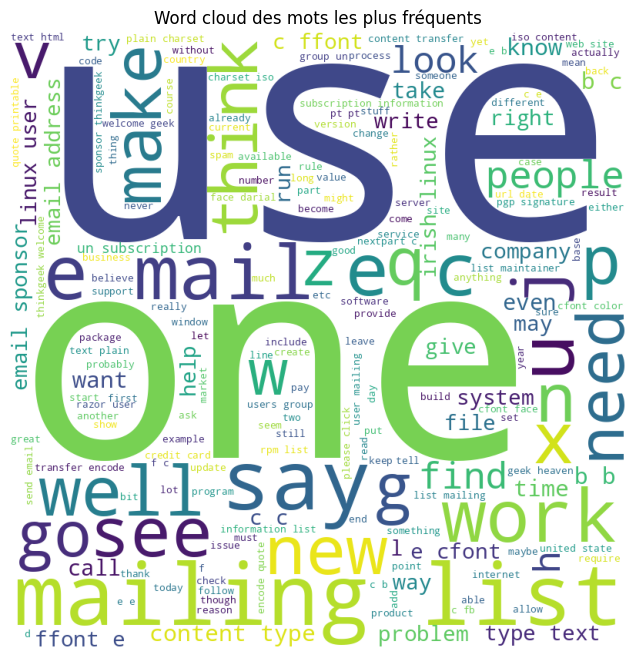

In [37]:
from wordcloud import WordCloud

texte_global = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    min_font_size=10
).generate(texte_global)

plt.figure(figsize=(8,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word cloud des mots les plus fréquents")
plt.show()


Bar plot des mots les plus communs

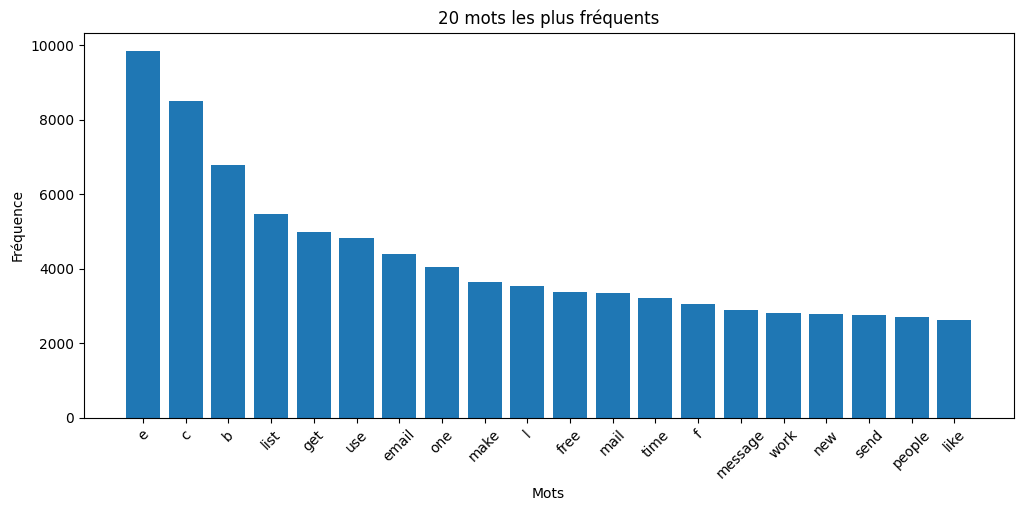

In [36]:
import matplotlib.pyplot as plt

words, freqs = zip(*counter.most_common(20))

plt.figure(figsize=(12,5))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("20 mots les plus fréquents")
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.show()


Histogramme de la longueur des mails

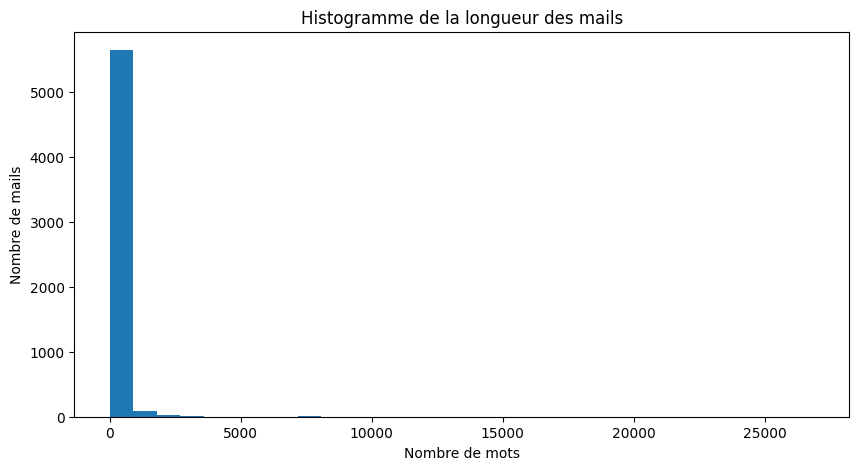

In [38]:
plt.figure(figsize=(10,5))
plt.hist(df["length_words"], bins=30)
plt.title("Histogramme de la longueur des mails")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de mails")
plt.show()


In [39]:
df.columns


Index(['CATEGORY', 'MESSAGE', 'FILE_NAME', 'MESSAGE_CLEAN', 'clean_text',
       'bert_vector', 'length_words'],
      dtype='object')

In [40]:
# On reconstruit un texte clair à partir des tokens nettoyés
df["clean_text"] = df["MESSAGE_CLEAN"].apply(lambda tokens: " ".join(tokens))

df[["CATEGORY", "clean_text"]].head()


,CATEGORY,clean_text
0,1,dear homeowner interest rate low point year he...
1,1,attention must computer user new special packa...
2,1,multi part message mime format nextpart cdc c ...
3,1,important information new domain name finally ...
4,1,bottom line give away cd free people like one ...


## Conclusion

Les emails ont été transformés en représentations numériques à l’aide de plusieurs méthodes. Le modèle Bag of Words génère une matrice de dimension 5796 × 130 951, illustrant la richesse lexicale du corpus. L’analyse exploratoire montre que les emails sont relativement longs, avec une moyenne d’environ 183 mots par mail, et met en évidence les mots les plus fréquents grâce aux visualisations (word cloud, bar plots et histogrammes), permettant une meilleure compréhension de la structure globale du corpus.

## 5) Topic Modeling sur les emails (LDA)

Imports des librairies

In [41]:
import sys
!{sys.executable} -m pip install pyLDAvis gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.4 MB/s eta 0:00:00


Préparation des données pour LDA

In [42]:
from gensim import corpora

# chaque mail est déjà tokenisé et nettoyé
texts = df["MESSAGE_CLEAN"].tolist()

# création du dictionnaire (mot -> id)
dictionary = corpora.Dictionary(texts)

# filtrer les mots trop rares ou trop fréquents (important pour LDA)
dictionary.filter_extremes(no_below=10, no_above=0.5)

# conversion en Bag of Words
corpus = [dictionary.doc2bow(text) for text in texts]

print(dictionary)
print("\n--- Exemple de corpus (BoW) ---")
print(corpus[:2])


Dictionary<6501 unique tokens: ['buyer', 'credit', 'dear', 'equity', 'even']...>

--- Exemple de corpus (BoW) ---
[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 4), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 2), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 2), (43, 1), (44, 1)], [(11, 1), (21, 1), (25, 1), (30, 1), (32, 1), (40, 1), (42, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 3), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 2), (61, 1), (62, 2), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 2), (73, 1), (74, 1), (75, 2), (76, 1), (77, 1), (78, 2), (79, 2), (80, 1), (81, 1), (82, 1), (83, 1), (84, 2), (85, 1), (86, 1), (87, 2), (88, 1), (89, 1), (90, 1), (91, 1), (

Entraînement du modèle LDA

In [43]:
from gensim.models import LdaModel

num_topics = 5

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=15
)

print(f"--- LDA entraîné avec {num_topics} topics ---")
lda_model.print_topics()


--- LDA entraîné avec 5 topics ---


[(0,
  '0.008*"say" + 0.006*"people" + 0.006*"one" + 0.005*"year" + 0.005*"make" + 0.005*"would" + 0.005*"company" + 0.004*"time" + 0.004*"world" + 0.004*"well"'),
 (1,
  '0.014*"email" + 0.012*"free" + 0.009*"mail" + 0.009*"receive" + 0.008*"click" + 0.008*"e" + 0.008*"address" + 0.008*"send" + 0.008*"get" + 0.008*"please"'),
 (2,
  '0.011*"file" + 0.011*"use" + 0.010*"get" + 0.010*"spam" + 0.009*"razor" + 0.009*"rpm" + 0.009*"mailing" + 0.009*"user" + 0.008*"write" + 0.007*"server"'),
 (3,
  '0.065*"c" + 0.061*"e" + 0.054*"b" + 0.027*"l" + 0.024*"f" + 0.017*"u" + 0.017*"n" + 0.016*"x" + 0.015*"r" + 0.015*"v"'),
 (4,
  '0.012*"use" + 0.012*"linux" + 0.009*"message" + 0.009*"group" + 0.009*"get" + 0.008*"write" + 0.008*"exmh" + 0.008*"information" + 0.008*"irish" + 0.007*"subscription"')]

Affichage des topics

In [44]:
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {idx} : {topic}")


Topic 0 : 0.008*"say" + 0.006*"people" + 0.006*"one" + 0.005*"year" + 0.005*"make" + 0.005*"would" + 0.005*"company" + 0.004*"time" + 0.004*"world" + 0.004*"well"
Topic 1 : 0.014*"email" + 0.012*"free" + 0.009*"mail" + 0.009*"receive" + 0.008*"click" + 0.008*"e" + 0.008*"address" + 0.008*"send" + 0.008*"get" + 0.008*"please"
Topic 2 : 0.011*"file" + 0.011*"use" + 0.010*"get" + 0.010*"spam" + 0.009*"razor" + 0.009*"rpm" + 0.009*"mailing" + 0.009*"user" + 0.008*"write" + 0.007*"server"
Topic 3 : 0.065*"c" + 0.061*"e" + 0.054*"b" + 0.027*"l" + 0.024*"f" + 0.017*"u" + 0.017*"n" + 0.016*"x" + 0.015*"r" + 0.015*"v"
Topic 4 : 0.012*"use" + 0.012*"linux" + 0.009*"message" + 0.009*"group" + 0.009*"get" + 0.008*"write" + 0.008*"exmh" + 0.008*"information" + 0.008*"irish" + 0.007*"subscription"


## 6) VISUALISATION ET ANALYSE DES TOPICS

In [45]:
import pyLDAvis
import pyLDAvis.gensim_models as gensim_models

lda_display = gensim_models.prepare(
    lda_model,
    corpus,
    dictionary,
    sort_topics=False
)

pyLDAvis.display(lda_display)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Sauvegarde de la visualisation

In [46]:
pyLDAvis.save_html(lda_display, "lda_topics_emails.html")

from google.colab import files
files.download("lda_topics_emails.html")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic dominant par email

In [47]:
def get_dominant_topic(model, bow):
    topics = model.get_document_topics(bow)
    if len(topics) == 0:
        return None
    return max(topics, key=lambda x: x[1])[0]

df["dominant_topic"] = [get_dominant_topic(lda_model, bow) for bow in corpus]

df[["MESSAGE", "dominant_topic"]].head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,MESSAGE,dominant_topic
0,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",1
1,ATTENTION: This is a MUST for ALL Computer Use...,1
2,This is a multi-part message in MIME format.\n...,1
3,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,1
4,This is the bottom line. If you can GIVE AWAY...,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Répartition des topics dans le corpus

In [48]:
df["dominant_topic"].value_counts()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
dominant_topic,
0,1533
1,1500
4,1342
2,1218
3,203


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Conclusion

Le Topic Modeling par LDA a permis d’identifier 5 thématiques principales au sein des emails. Les mots dominants de chaque topic révèlent des thèmes récurrents tels que la communication par email, les offres promotionnelles, les messages techniques ou encore les abonnements. La visualisation interactive facilite l’interprétation des topics et met en évidence la diversité des sujets abordés dans le corpus.